# Aggregated discovery-chain simulation analysis

This notebook reads the simulated PsyNet export directly and checks the compact local run: one chain, easy condition, two trials per generation, and three participant-facing generations.

In [1]:
from pathlib import Path
import csv, json, zipfile
from collections import Counter

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 50

zip_path = Path("../simulated_data.zip")
assert zip_path.exists(), zip_path

def read_csv(name):
    with zipfile.ZipFile(zip_path) as z:
        with z.open(f"regular/data/{name}.csv") as f:
            return list(csv.DictReader((line.decode("utf-8") for line in f)))

trials = read_csv("DiscoveryTrial")
nodes = read_csv("DiscoveryChainNode")
print(f"Loaded {len(trials)} trials and {len(nodes)} chain nodes from {zip_path}.")

Loaded 6 trials and 4 chain nodes from ../simulated_data.zip.


In [2]:
trial_rows = []
for row in trials:
    answer = json.loads(row["answer"])
    incoming = answer["incoming_message_set"]
    trial_rows.append({
        "trial_id": int(row["id"]),
        "participant_id": int(row["participant_id"]),
        "generation": answer["generation_index"],
        "chain": answer["chain_id"],
        "condition": answer["condition"],
        "points": answer["game"]["total_points"],
        "incoming_source": incoming["source_generation_index"],
        "incoming_messages": len(incoming["messages"]),
        "actions_saved": len(answer["game"]["actions"]),
        "events_saved": len(answer["game"]["events"]),
        "notebook_notes": len(answer["messages"]["notebook"]),
    })

for row in trial_rows:
    print(row)

counts = Counter(row["generation"] for row in trial_rows)
assert counts == {0: 2, 1: 2, 2: 2}
assert all(row["incoming_messages"] == 0 for row in trial_rows if row["generation"] == 0)
assert all(row["incoming_source"] == 0 and row["incoming_messages"] == 2 for row in trial_rows if row["generation"] == 1)
assert all(row["incoming_source"] == 1 and row["incoming_messages"] == 2 for row in trial_rows if row["generation"] == 2)
print("Generation and incoming-message assertions passed.")

{'trial_id': 1, 'participant_id': 1, 'generation': 0, 'chain': 0, 'condition': 'easy', 'points': 20, 'incoming_source': None, 'incoming_messages': 0, 'actions_saved': 4, 'events_saved': 39, 'notebook_notes': 0}
{'trial_id': 2, 'participant_id': 2, 'generation': 0, 'chain': 0, 'condition': 'easy', 'points': 20, 'incoming_source': None, 'incoming_messages': 0, 'actions_saved': 4, 'events_saved': 50, 'notebook_notes': 0}
{'trial_id': 3, 'participant_id': 3, 'generation': 1, 'chain': 0, 'condition': 'easy', 'points': 20, 'incoming_source': 0, 'incoming_messages': 2, 'actions_saved': 4, 'events_saved': 39, 'notebook_notes': 1}
{'trial_id': 4, 'participant_id': 4, 'generation': 1, 'chain': 0, 'condition': 'easy', 'points': 20, 'incoming_source': 0, 'incoming_messages': 2, 'actions_saved': 4, 'events_saved': 31, 'notebook_notes': 1}
{'trial_id': 5, 'participant_id': 5, 'generation': 2, 'chain': 0, 'condition': 'easy', 'points': 20, 'incoming_source': 1, 'incoming_messages': 2, 'actions_saved'

In [3]:
node_rows = []
for row in nodes:
    definition = json.loads(row["definition"])
    aggregation = json.loads(row["aggregation"]) if row.get("aggregation") else None
    node_rows.append({
        "node_id": int(row["id"]),
        "degree": int(row["degree"]),
        "generation_definition": definition["generation_index"],
        "incoming_source": definition["incoming_message_set"]["source_generation_index"],
        "incoming_messages": len(definition["incoming_message_set"]["messages"]),
        "aggregation_inputs": len(aggregation["inputs"]) if aggregation else 0,
        "aggregation_selected": len(aggregation["selected_messages"]) if aggregation else 0,
        "selected_trial_ids": [m["source_trial_id"] for m in aggregation["selected_messages"]] if aggregation else [],
    })

for row in node_rows:
    print(row)

assert node_rows[0]["aggregation_inputs"] == 2 and node_rows[0]["aggregation_selected"] == 2
assert node_rows[1]["aggregation_inputs"] == 2 and node_rows[1]["aggregation_selected"] == 2
print("Aggregation audit assertions passed.")

{'node_id': 1, 'degree': 0, 'generation_definition': 0, 'incoming_source': None, 'incoming_messages': 0, 'aggregation_inputs': 2, 'aggregation_selected': 2, 'selected_trial_ids': [1, 2]}
{'node_id': 2, 'degree': 1, 'generation_definition': 1, 'incoming_source': 0, 'incoming_messages': 2, 'aggregation_inputs': 2, 'aggregation_selected': 2, 'selected_trial_ids': [3, 4]}
{'node_id': 3, 'degree': 2, 'generation_definition': 2, 'incoming_source': 1, 'incoming_messages': 2, 'aggregation_inputs': 2, 'aggregation_selected': 2, 'selected_trial_ids': [5, 6]}
{'node_id': 4, 'degree': 3, 'generation_definition': 3, 'incoming_source': 2, 'incoming_messages': 2, 'aggregation_inputs': 0, 'aggregation_selected': 0, 'selected_trial_ids': []}
Aggregation audit assertions passed.


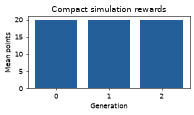

In [4]:
generations = sorted(counts)
points = [sum(row["points"] for row in trial_rows if row["generation"] == g) / counts[g] for g in generations]
plt.figure(figsize=(4, 2.4))
plt.bar([str(g) for g in generations], points, color="#255f99")
plt.xlabel("Generation")
plt.ylabel("Mean points")
plt.title("Compact simulation rewards")
plt.tight_layout()
plt.show()

## Interpretation

The compact simulation completed the requested three participant-facing generations. Generation 1 trials received two messages selected from generation 0, and generation 2 trials received two messages selected from generation 1. Aggregation audit data are present in PsyNet node variables, and trial answers contain game actions, events, outgoing messages, incoming message sets, notebook data for later generations, and timing metadata. The reward plot is deterministic bot evidence, not a behavioral claim about human participants.